<a href="https://colab.research.google.com/github/blkmonday/Building-A-Virtual-HomeLab-on-MacOS/blob/main/AI_Phishing_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

Downloading a phishing dataset from kaggle  and displaying the first 5 rows of this dataset

In [ ]:
uploaded = files.upload()

Saving CEAS_08.csv to CEAS_08.csv


In [ ]:
import pandas as pd
df= pd.read_csv('CEAS_08.csv')
df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


Finding the value of total emails in the dataset and which are phishing emails or legit

In [ ]:
df['label'].value_counts()

,count
label,
1,21842
0,17312


In [ ]:
df.shape

(39154, 7)

There are 39,154 total emails and they are 21,842 being phishing emails and 17,312 being legit

Example of a phishing email vs. a real email in this dataset

In [ ]:
## Phishing email
print('=== PHISHING EMAIL ===')
print(df[df['label'] == 1]['body'].iloc[0])

=== PHISHING EMAIL ===
Buck up, your troubles caused by small dimension will soon be over!
Become a lover no woman will be able to resist!
http://whitedone.com/


come. Even as Nazi tanks were rolling down the streets, the dreamersphilosopher or a journalist. He was still not sure.I do the same.


As shown the phishing email shows clear red flags with emotion saying 'your troubles will soon be over', having a suspicious link, and the text not making sense

In [ ]:
## Real email
print('=== LEGIT EMAIL ===')
print(df[df['label'] == 0]['body'].iloc[0])

=== LEGIT EMAIL ===
Would anyone object to removing .so from this list?  The .so TLD is  
basically dead and we've found that lots of bogus domains like lib*.so  
are being caught by this.  Also sometimes you'll have spammers who are  
putting in gibberish or funny punctuation and you'll get sentences  
like 'blah blah.So this is'.  It also occurs with a couple of other  
domains but .so is by far the worst.

For more info on the .so domain you can read about it here: http://en.wikipedia.org/wiki/.so_%28domain_name%29

Michael

On Feb 7, 2008, at 9:23 PM, wrzzpv@apache.org wrote:

> Author: sidney
> Date: Thu Feb  7 19:22:58 2008
> New Revision: 619753
>
> URL: http://svn.apache.org/viewvc?rev=619753&view=rev
> Log:
> bug 5813: correct TLD lookup to match current ICANN list and add all  
> TLDs to regression tests
>
> Modified:
>    spamassassin/trunk/lib/Mail/SpamAssassin/PerMsgStatus.pm
>    spamassassin/trunk/lib/Mail/SpamAssassin/Util/ 
> RegistrarBoundaries.pm
>    spamassassin/tr

The real email is very long and tehcnical wtih it being a threaded conversation betweens to developers.

The AI will be able to read and pick up on patterns like the ones shown in the examples

In [ ]:
df['email_length'] = df['body'].apply(len)

print('Average phishing email length: ')
print(df[df['label'] == 1]['email_length'].mean())

print("\nAverage legit email length")
print(df[df['label'] == 0]['email_length'].mean())

Average phishing email length: 
801.3794524310961

Average legit email length
2542.1862869685765


Finding the average length of the two types of emails counting the characters it has
Phishing emails tend to be shorter as seen in the example averaging 801 characters while real emails tend to be longer and have real substance

Displayed down below is a graph of such

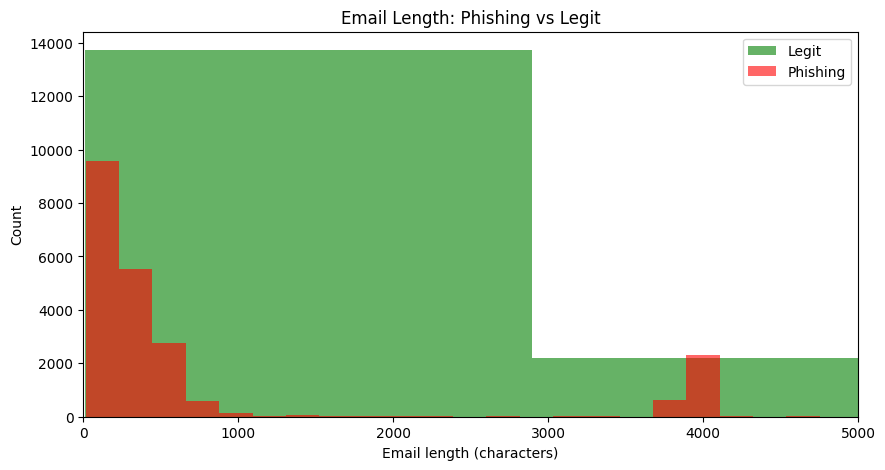

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.hist(df[df['label'] == 0]['email_length'], bins=50, alpha = .6, color = 'green', label = 'Legit')
plt.hist(df[df['label'] == 1]['email_length'], bins=50, alpha = .6, color = 'red', label = 'Phishing')
plt.xlabel('Email length (characters)')
plt.ylabel('Count')
plt.title('Email Length: Phishing vs Legit')
plt.legend()
plt.xlim(0,5000)
plt.show()

Patterns recognition will be followed by searching urgency words in emails in which phishing emails usually use.

Urgency words that we will be using are: urgent, verify, verification, account, password, click, suspend, unauthorized, immedietely, warning, required, and expiration

In [ ]:
urgency_words = ['urgent', 'verification', 'verify', 'account', 'password', 'click', 'suspend', 'unauthorized', 'immedietely', 'warning', 'required', 'expiration']

def count_urgency(text):
  text = str(text).lower()
  count = 0
  for word in urgency_words:
    if word in text:
      count += 1
  return count

df['urgency_count'] = df['body'].apply(count_urgency)

print("Average amount of urgency keywords in phishing emails:")
print(df[df['label']== 1]['urgency_count'].mean())

print("\nAverage urgency words in legit emails:")
print(df[df['label']== 0]['urgency_count'].mean())


Average ammount of urgency keywords in phishing emails:
0.163309220767329

Average urgency words in legit emails:
0.32538123844731975


Contrary to my believe there is a higher percenetage of urgency words in real emails presented. In this dataset it may contain mostly spam style or not use urgency as much making keyword not a strong indicator for the model

Now we will search for URLs as a feature this dataset has a url column so information be will pull from that

In [ ]:
print("Average URL count in phishing emails:")
print(df[df['label'] == 1]['urls'].mean())

print('\nAverage URL count in legit emails:')
print(df[df['label'] == 0]['urls'].mean())

print('\nTotal amount of URLs in all emails:')
print(df['urls'])

Average URL count in phishing emails:
0.6816683453896163

Average URL count in legit emails:
0.6552102587800369

Total amount of URLs in all emails:
39149    0
39150    0
39151    0
39152    0
39153    1
Name: urls, dtype: int64


To make this model more precise finding the most popular word may be choice of action as basic ones didnt give good insight of the differences between phishing emails and legit email so a code will be conducted to find so and see if results change
Counter will have to be imported to find the ammount of time a word appears and get_words will count how many times a word appears

In [ ]:
from collections import Counter
import re

def get_words(texts):
    all_words = []
    for text in texts:
      text = str(text).lower()
      text = re.sub(r'[^a-zA-Z\s]', '', text)
      words = text.split()
      all_words.extend(words)
    return all_words

phishing_words = get_words(df[df['label']== 1]['body'])
legit_words = get_words(df[df['label']== 0]['body'])

phishing_common = Counter(phishing_words).most_common(30)
legit_common = Counter(legit_words).most_common(30)

print('Top 30 phishing words:')
for word, count in phishing_common:
  print(f"{word}: {count}")

print('Top 30 legit words:')
for word,count in legit_common:
  print(f"{word}: {count}")

Top 30 phishing words:
to: 47737
the: 40242
of: 31995
a: 31254
your: 23025
and: 22702
in: 20092
you: 17928
from: 17591
top: 15017
is: 13763
for: 13211
news: 12755
cnncom: 11603
on: 10726
as: 10553
our: 9785
at: 9737
by: 8931
cnn: 8744
network: 8717
settings: 8677
this: 8675
cable: 8673
with: 8505
have: 8169
all: 8157
or: 8140
it: 8073
we: 7003
Top 30 legit words:
the: 205270
to: 136796
and: 101195
of: 97802
a: 91641
in: 86278
is: 60866
for: 56845
i: 54716
that: 46653
on: 43914
this: 42774
it: 42411
as: 42014
you: 38416
be: 33868
with: 32546
submissionid: 32246
from: 30321
at: 28450
no: 28031
are: 25269
not: 25156
or: 24098
have: 22884
by: 21966
if: 21122
submission: 20136
added: 19637
sender: 18839


As seen a lot of common words are show which are stop words in which will be looked past.
Words that stand out in fishing emails:
 news, cnncom, network, settings, cnn, top, cable

 While on the legit side there are more professional words utilized like submission, added, sender from real conversations

To combat stop words we will run a code to filter them out

In [ ]:
stopwords = {'the', 'a', 'an', 'is', 'it', 'to', 'of', 'and', 'in', 'for', 'on', 'that', 'this', 'with', 'you', 'your', 'be', 'are', 'was', 'have', 'has', 'will', 'can', 'do', 'if', 'at', 'from', 'or', 'not', 'but', 'by', 'as', 'all', 'our', 'my', 'me', 'i', 'they', 'them', 'their', 'he', 'she', 'his', 'her', 'so', 'no', 'its', 'been', 'would', 'about', 'up', 'out', 'what', 'which', 'who' 'more', 'than', 'other', 'into', 'could', 'there'}

phishing_filtered = [(w, c)for w, c in Counter(phishing_words).most_common(100)
                    if w not in stopwords and len(w) > 2][:20]

legit_filtered = [(w, c)for w, c in Counter(legit_words).most_common(100)
                  if w not in stopwords and len(w) > 2][:20]

print('Top 20 phishing words(No stopwords):')
for word, count in phishing_filtered:
    print(f" {word}: {count}")

print('\n Top 20 legit words(No stopwords):')
for word, count in legit_filtered:
    print(f"  {word}: {count}")



Top 20 phishing words(No stopwords):
 top: 15017
 news: 12755
 cnncom: 11603
 cnn: 8744
 network: 8717
 settings: 8677
 cable: 8673
 email: 6581
 time: 6228
 going: 5988
 videos: 5927
 daily: 5900
 stories: 5862
 lllp: 5860
 one: 5702
 replica: 5649
 alert: 5628
 here: 5578
 aug: 5521
 after: 4900

 Top 20 legit words(No stopwords):
  submissionid: 32246
  submission: 20136
  added: 19637
  sender: 18839
  same: 18477
  notes: 18323
  virus: 16962
  total: 14762
  wrote: 13466
  list: 12335
  more: 12225
  new: 11754
  use: 10540
  email: 10248
  one: 10099
  message: 9217
  university: 9000
  feb: 8981
  when: 8893
  like: 8867


Now we have a more accurate list without fodder as before we see words we already recorded like top, news, cnncom, network, settings, and cable. We also see new words that are utilized in phishing like email, time, going, videos, daily, stories, lllp, one, replica, alert, here, aug, and after.
Some of these variables match alongiside legit emails

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
project_path = '/content/drive/MyDrive/Phishing_Detection_Projection'
os.makedirs(project_path, exist_ok= True)

df.to_csv(f'{project_path}/phishing_cleaned.csv', index=False)
print("Saved")
print(f"Location: {project_path}/phishing_cleaned.csv")
print(f"Total emails: {len(df)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved
Location: /content/drive/MyDrive/Phishing_Detection_Projection/phishing_cleaned.csv
Total emails: 39154
